In [1]:
import numpy as np

hours = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)
marks = np.array([40, 45, 50, 55, 60, 65]).reshape(-1, 1)

X = np.hstack([np.ones_like(hours), hours])
y = marks

beta = np.linalg.inv(X.T @ X) @ X.T @ y
print("Regression Coefficients:\n", beta)
print("Intercept:", beta[0,0], "Slope:", beta[1,0])

y_pred = X @ beta
print("\nPredicted Marks:\n", y_pred)

mean_pred = np.mean(y_pred)
std_pred = np.std(y_pred)
print("\nMean of predicted marks:", round(mean_pred, 2))
print("Standard deviation of predicted marks:", round(std_pred, 2))

results = np.hstack([hours, y, y_pred])
print("\nHours | Actual | Predicted")
print(results)

np.savetxt("linear_regression_results.csv",
           results,
           delimiter=",",
           header="Hours,Actual_Marks,Predicted_Marks",
           comments="")

print("\nFile 'linear_regression_results.csv' saved.")

Regression Coefficients:
 [[35.]
 [ 5.]]
Intercept: 34.99999999999996 Slope: 4.999999999999993

Predicted Marks:
 [[40.]
 [45.]
 [50.]
 [55.]
 [60.]
 [65.]]

Mean of predicted marks: 52.5
Standard deviation of predicted marks: 8.54

Hours | Actual | Predicted
[[ 1. 40. 40.]
 [ 2. 45. 45.]
 [ 3. 50. 50.]
 [ 4. 55. 55.]
 [ 5. 60. 60.]
 [ 6. 65. 65.]]

File 'linear_regression_results.csv' saved.


In [2]:
new_hours = np.array([7, 8, 9]).reshape(-1, 1)
print("New study hours array:", new_hours)

New study hours array: [[7]
 [8]
 [9]]


In [3]:
X_new = np.hstack([np.ones_like(new_hours), new_hours])
y_pred_new = X_new @ beta

print("Predicted marks for new study hours:")
for i in range(len(new_hours)):
    print(f"{int(new_hours[i][0])} hours → {int(y_pred_new[i][0])} marks")

Predicted marks for new study hours:
7 hours → 69 marks
8 hours → 74 marks
9 hours → 79 marks


In [4]:
new_predictions = np.hstack([new_hours, y_pred_new])

np.savetxt("new_predictions.csv",
           new_predictions,
           delimiter=",",
           header="Study_Hours,Predicted_Marks",
           comments="")

print("File 'new_predictions.csv' saved.")

File 'new_predictions.csv' saved.


In [5]:
import pandas as pd
df_new_predictions = pd.read_csv('new_predictions.csv')
display(df_new_predictions)

,Study_Hours,Predicted_Marks
0,7.0,70.0
1,8.0,75.0
2,9.0,80.0


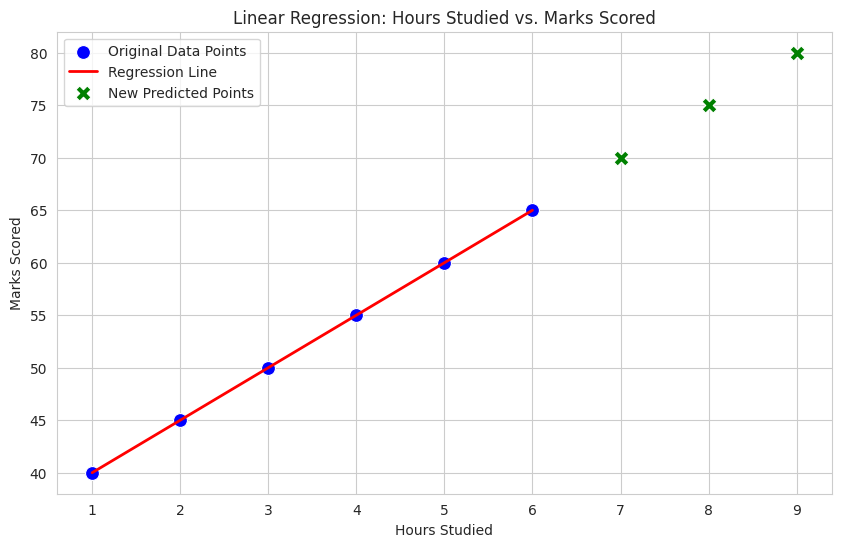

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure hours, marks, y_pred, new_hours, y_pred_new are flat arrays for plotting
hours_flat = hours.flatten()
marks_flat = marks.flatten()
y_pred_flat = y_pred.flatten()
new_hours_flat = new_hours.flatten()
y_pred_new_flat = y_pred_new.flatten()

plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

# Plot original data points
sns.scatterplot(x=hours_flat, y=marks_flat, color='blue', s=100, label='Original Data Points')

# Plot regression line
sns.lineplot(x=hours_flat, y=y_pred_flat, color='red', linewidth=2, label='Regression Line')

# Plot new predicted points
sns.scatterplot(x=new_hours_flat, y=y_pred_new_flat, color='green', s=120, marker='X', label='New Predicted Points')

plt.title('Linear Regression: Hours Studied vs. Marks Scored')
plt.xlabel('Hours Studied')
plt.ylabel('Marks Scored')
plt.legend()
plt.show()